# Information Diffusion Across Investor Networks

## Research question

How do network structure and the probability of sharing information
affect the speed and reach of information diffusion among investors?

## Model

The model contains 100 investors connected through an undirected
network with 200 edges. Five randomly selected investors initially
know a piece of information.

In each round, every informed investor attempts to share with a
specified probability. If they share, they randomly select one
neighbour. An uninformed recipient becomes informed and can begin
sharing in the next round.

## Main assumptions

- Information is accurate, identical for everyone and always accepted.
- Investors remain informed once they receive the information.
- All investors have the same probability of sharing.
- Connections remain fixed during each simulation.
- Each informed investor makes at most one contact per round.
- A round is an abstract time step, rather than a day or trading session.

## Scope

This is a stylised simulation of information transmission.
It does not model trading, stock prices or investment performance,
and it is not calibrated to observed investor networks.

In [1]:
import random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [2]:
def simulate_network_diffusion(
    network,
    sharing_probability,
    seed=42,
    number_of_rounds=30
):
    rng = random.Random(seed)

    starting_investors = rng.sample(list(network.nodes()), 5)
    informed = set(starting_investors)
    history = [len(informed)]

    for round_number in range(1, number_of_rounds + 1):
        newly_informed = set()

        for investor in sorted(informed):
            if rng.random() < sharing_probability:
                neighbours = list(network.neighbors(investor))

                if neighbours:
                    recipient = rng.choice(neighbours)

                    if recipient not in informed:
                        newly_informed.add(recipient)

        informed.update(newly_informed)
        history.append(len(informed))

    return history

In [3]:
example_network = nx.watts_strogatz_graph(
    n=100,
    k=4,
    p=0,
    seed=42
)

example_results = simulate_network_diffusion(
    network=example_network,
    sharing_probability=0.5,
    seed=42,
    number_of_rounds=30
)

assert len(example_results) == 31
assert example_results[0] == 5
assert all(5 <= count <= 100 for count in example_results)
assert all(
    earlier <= later
    for earlier, later in zip(example_results, example_results[1:])
)

print("Model checks passed.")
print("Informed after 30 rounds:", example_results[-1])

Model checks passed.
Informed after 30 rounds: 88


## Experiment 1: Network structure

Compare six rewiring probabilities while holding sharing probability
at 50%. Each scenario uses 20 network seeds and 10 diffusion runs
per network, giving 200 runs per scenario.

For the ring, network seeds produce the same structure, but all
200 diffusion seeds are distinct. For rewired networks, runs are
grouped within 20 generated networks.

In [4]:
rewiring_probabilities = [0.0, 0.05, 0.1, 0.25, 0.5, 1.0]
summary = []

for rewiring_probability in rewiring_probabilities:
    final_counts = []
    times_to_90 = []

    for network_seed in range(20):
        network = nx.watts_strogatz_graph(
            n=100,
            k=4,
            p=rewiring_probability,
            seed=network_seed
        )

        for run_seed in range(10):
            diffusion_seed = network_seed * 10 + run_seed

            results = simulate_network_diffusion(
                network=network,
                sharing_probability=0.5,
                seed=diffusion_seed,
                number_of_rounds=30
            )

            final_counts.append(results[-1])

            for round_number, informed_count in enumerate(results):
                if informed_count >= 90:
                    times_to_90.append(round_number)
                    break

    average_time = None

    if times_to_90:
        average_time = float(np.mean(times_to_90))

    summary.append({
        "rewiring_probability": rewiring_probability,
        "average_final_informed": float(np.mean(final_counts)),
        "success_rate": len(times_to_90) / len(final_counts),
        "average_time_successful": average_time
    })

    print(
        f"Rewiring: {rewiring_probability:.0%}"
        f" | Average informed: {np.mean(final_counts):.1f}"
        f" | Reaching 90%: {len(times_to_90) / len(final_counts):.1%}"
    )

Rewiring: 0% | Average informed: 77.4 | Reaching 90%: 22.0%
Rewiring: 5% | Average informed: 93.1 | Reaching 90%: 74.5%
Rewiring: 10% | Average informed: 97.2 | Reaching 90%: 95.0%
Rewiring: 25% | Average informed: 99.6 | Reaching 90%: 100.0%
Rewiring: 50% | Average informed: 99.6 | Reaching 90%: 100.0%
Rewiring: 100% | Average informed: 99.6 | Reaching 90%: 100.0%


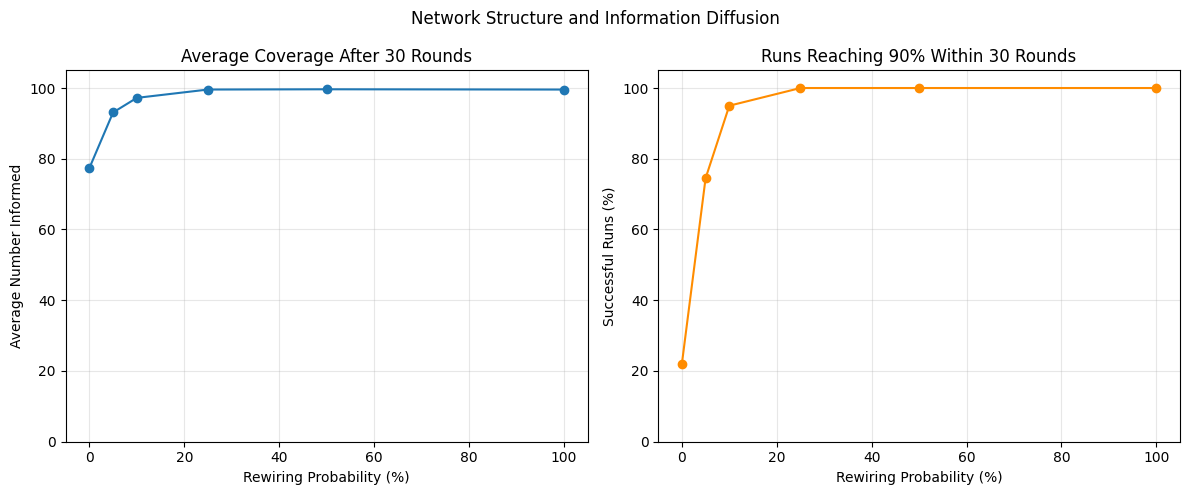

In [5]:
rewiring_percentages = [
    row["rewiring_probability"] * 100
    for row in summary
]

average_coverage = [
    row["average_final_informed"]
    for row in summary
]

success_percentages = [
    row["success_rate"] * 100
    for row in summary
]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(
    rewiring_percentages,
    average_coverage,
    marker="o"
)
axes[0].set_title("Average Coverage After 30 Rounds")
axes[0].set_xlabel("Rewiring Probability (%)")
axes[0].set_ylabel("Average Number Informed")
axes[0].set_ylim(0, 105)
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    rewiring_percentages,
    success_percentages,
    marker="o",
    color="darkorange"
)
axes[1].set_title("Runs Reaching 90% Within 30 Rounds")
axes[1].set_xlabel("Rewiring Probability (%)")
axes[1].set_ylabel("Successful Runs (%)")
axes[1].set_ylim(0, 105)
axes[1].grid(True, alpha=0.3)

fig.suptitle("Network Structure and Information Diffusion")
plt.tight_layout()
plt.show()

### Finding

At a 50% sharing probability, increasing rewiring from 0% to 10%
raised average coverage after 30 rounds from 77.4 to 97.2 investors.
The proportion of runs reaching 90% coverage rose from 22% to 95%.

Final coverage approached its maximum at 25% rewiring, with little
further improvement at the observation horizon. This does not imply
identical diffusion speeds: time-to-threshold results show differences
that final coverage can conceal.

Lines connect the tested settings as a visual guide; intermediate
rewiring probabilities were not simulated.

## Experiment 2: Sharing frequency

Test whether the network comparison holds at sharing probabilities
of 25%, 50% and 100%.

Each sharing probability is tested with 0%, 10% and 100% rewiring,
using 20 network seeds and 10 diffusion runs per network.
All other model settings remain unchanged.

In [6]:
sensitivity_results = []

for sharing_probability in [0.25, 0.5, 1.0]:
    for rewiring_probability in [0.0, 0.1, 1.0]:
        final_counts = []
        successful_runs = 0

        for network_seed in range(20):
            network = nx.watts_strogatz_graph(
                n=100,
                k=4,
                p=rewiring_probability,
                seed=network_seed
            )

            for run_seed in range(10):
                diffusion_seed = network_seed * 10 + run_seed

                results = simulate_network_diffusion(
                    network=network,
                    sharing_probability=sharing_probability,
                    seed=diffusion_seed,
                    number_of_rounds=30
                )

                final_counts.append(results[-1])

                if results[-1] >= 90:
                    successful_runs += 1

        average_coverage = float(np.mean(final_counts))
        success_rate = successful_runs / len(final_counts)

        sensitivity_results.append({
            "sharing_probability": sharing_probability,
            "rewiring_probability": rewiring_probability,
            "average_coverage": average_coverage,
            "success_rate": success_rate
        })

        print(
            f"Sharing: {sharing_probability:.0%}"
            f" | Rewiring: {rewiring_probability:.0%}"
            f" | Average informed: {average_coverage:.1f}"
            f" | Reaching 90%: {success_rate:.1%}"
        )

Sharing: 25% | Rewiring: 0% | Average informed: 50.8 | Reaching 90%: 0.0%
Sharing: 25% | Rewiring: 10% | Average informed: 66.3 | Reaching 90%: 1.0%
Sharing: 25% | Rewiring: 100% | Average informed: 82.4 | Reaching 90%: 15.5%
Sharing: 50% | Rewiring: 0% | Average informed: 77.4 | Reaching 90%: 22.0%
Sharing: 50% | Rewiring: 10% | Average informed: 97.2 | Reaching 90%: 95.0%
Sharing: 50% | Rewiring: 100% | Average informed: 99.6 | Reaching 90%: 100.0%
Sharing: 100% | Rewiring: 0% | Average informed: 96.7 | Reaching 90%: 87.5%
Sharing: 100% | Rewiring: 10% | Average informed: 100.0 | Reaching 90%: 100.0%
Sharing: 100% | Rewiring: 100% | Average informed: 100.0 | Reaching 90%: 100.0%


### Finding

Rewired networks achieved greater average coverage at each tested
sharing probability. However, network shortcuts did not guarantee
rapid diffusion when sharing was infrequent.

At 25% sharing, even the fully rewired scenario reached 90% coverage
within 30 rounds in only 15.5% of runs. At 100% sharing, both rewired
scenarios reached the threshold in every run, compared with 87.5%
for the ring.

Within the tested settings, both network structure and sharing
frequency affected information diffusion.

## Limitations

- Networks are synthetic and are not calibrated to actual investor connections.
- Investors have identical sharing probabilities and always accept information.
- Information never changes, and informed investors never forget it.
- Rewiring changes several network properties simultaneously, so the
  experiment does not isolate a single mechanism.
- Results apply to the tested population, network density, starting
  informed count and 30-round observation window.
- Time-to-90% averages include only runs reaching the threshold within
  the observation window.
- Diffusion runs on the same network share its structure. They are not
  independent observations of different networks.
- The model does not include trading, prices or investment returns.

## Conclusion

Within this simulation, rewiring some local connections substantially
improved information coverage. Further increases produced smaller gains
in coverage after 30 rounds.

The sensitivity analysis showed that both network structure and sharing
frequency mattered. Shortcuts helped information spread, but infrequent
sharing could still prevent broad coverage within the observation window.

These findings illustrate a possible information transmission mechanism,
rather than providing empirical evidence about financial markets.

## Reproducibility

The notebook uses explicit random seeds for network generation and
diffusion. Run all code cells from top to bottom.

Required libraries: NumPy, NetworkX and Matplotlib.